# KIN 482D: Computational modeling of human sensorimotor control and learning

## Chapter 6: Learning as Inference
---

## Housekeeping

- Final project proposals due Wed
    - **Remember:** Lots of good articles posted under "Other Bayesian Studies" on Canvas landing page
    - Each textbook chapter has associated recommended articles as well
- Look out for typos - errata listed on Canvas
- Short Canvas quiz on Wed

---

![](images/fig6-1.png)

**Whiteboard until 6.3**

![](images/fig6-2.png)

![](images/fig6-3.png)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(context="paper", font_scale=1.2)
sns.set_style("ticks")

%config Inline.Backend.figure_format = "retina"

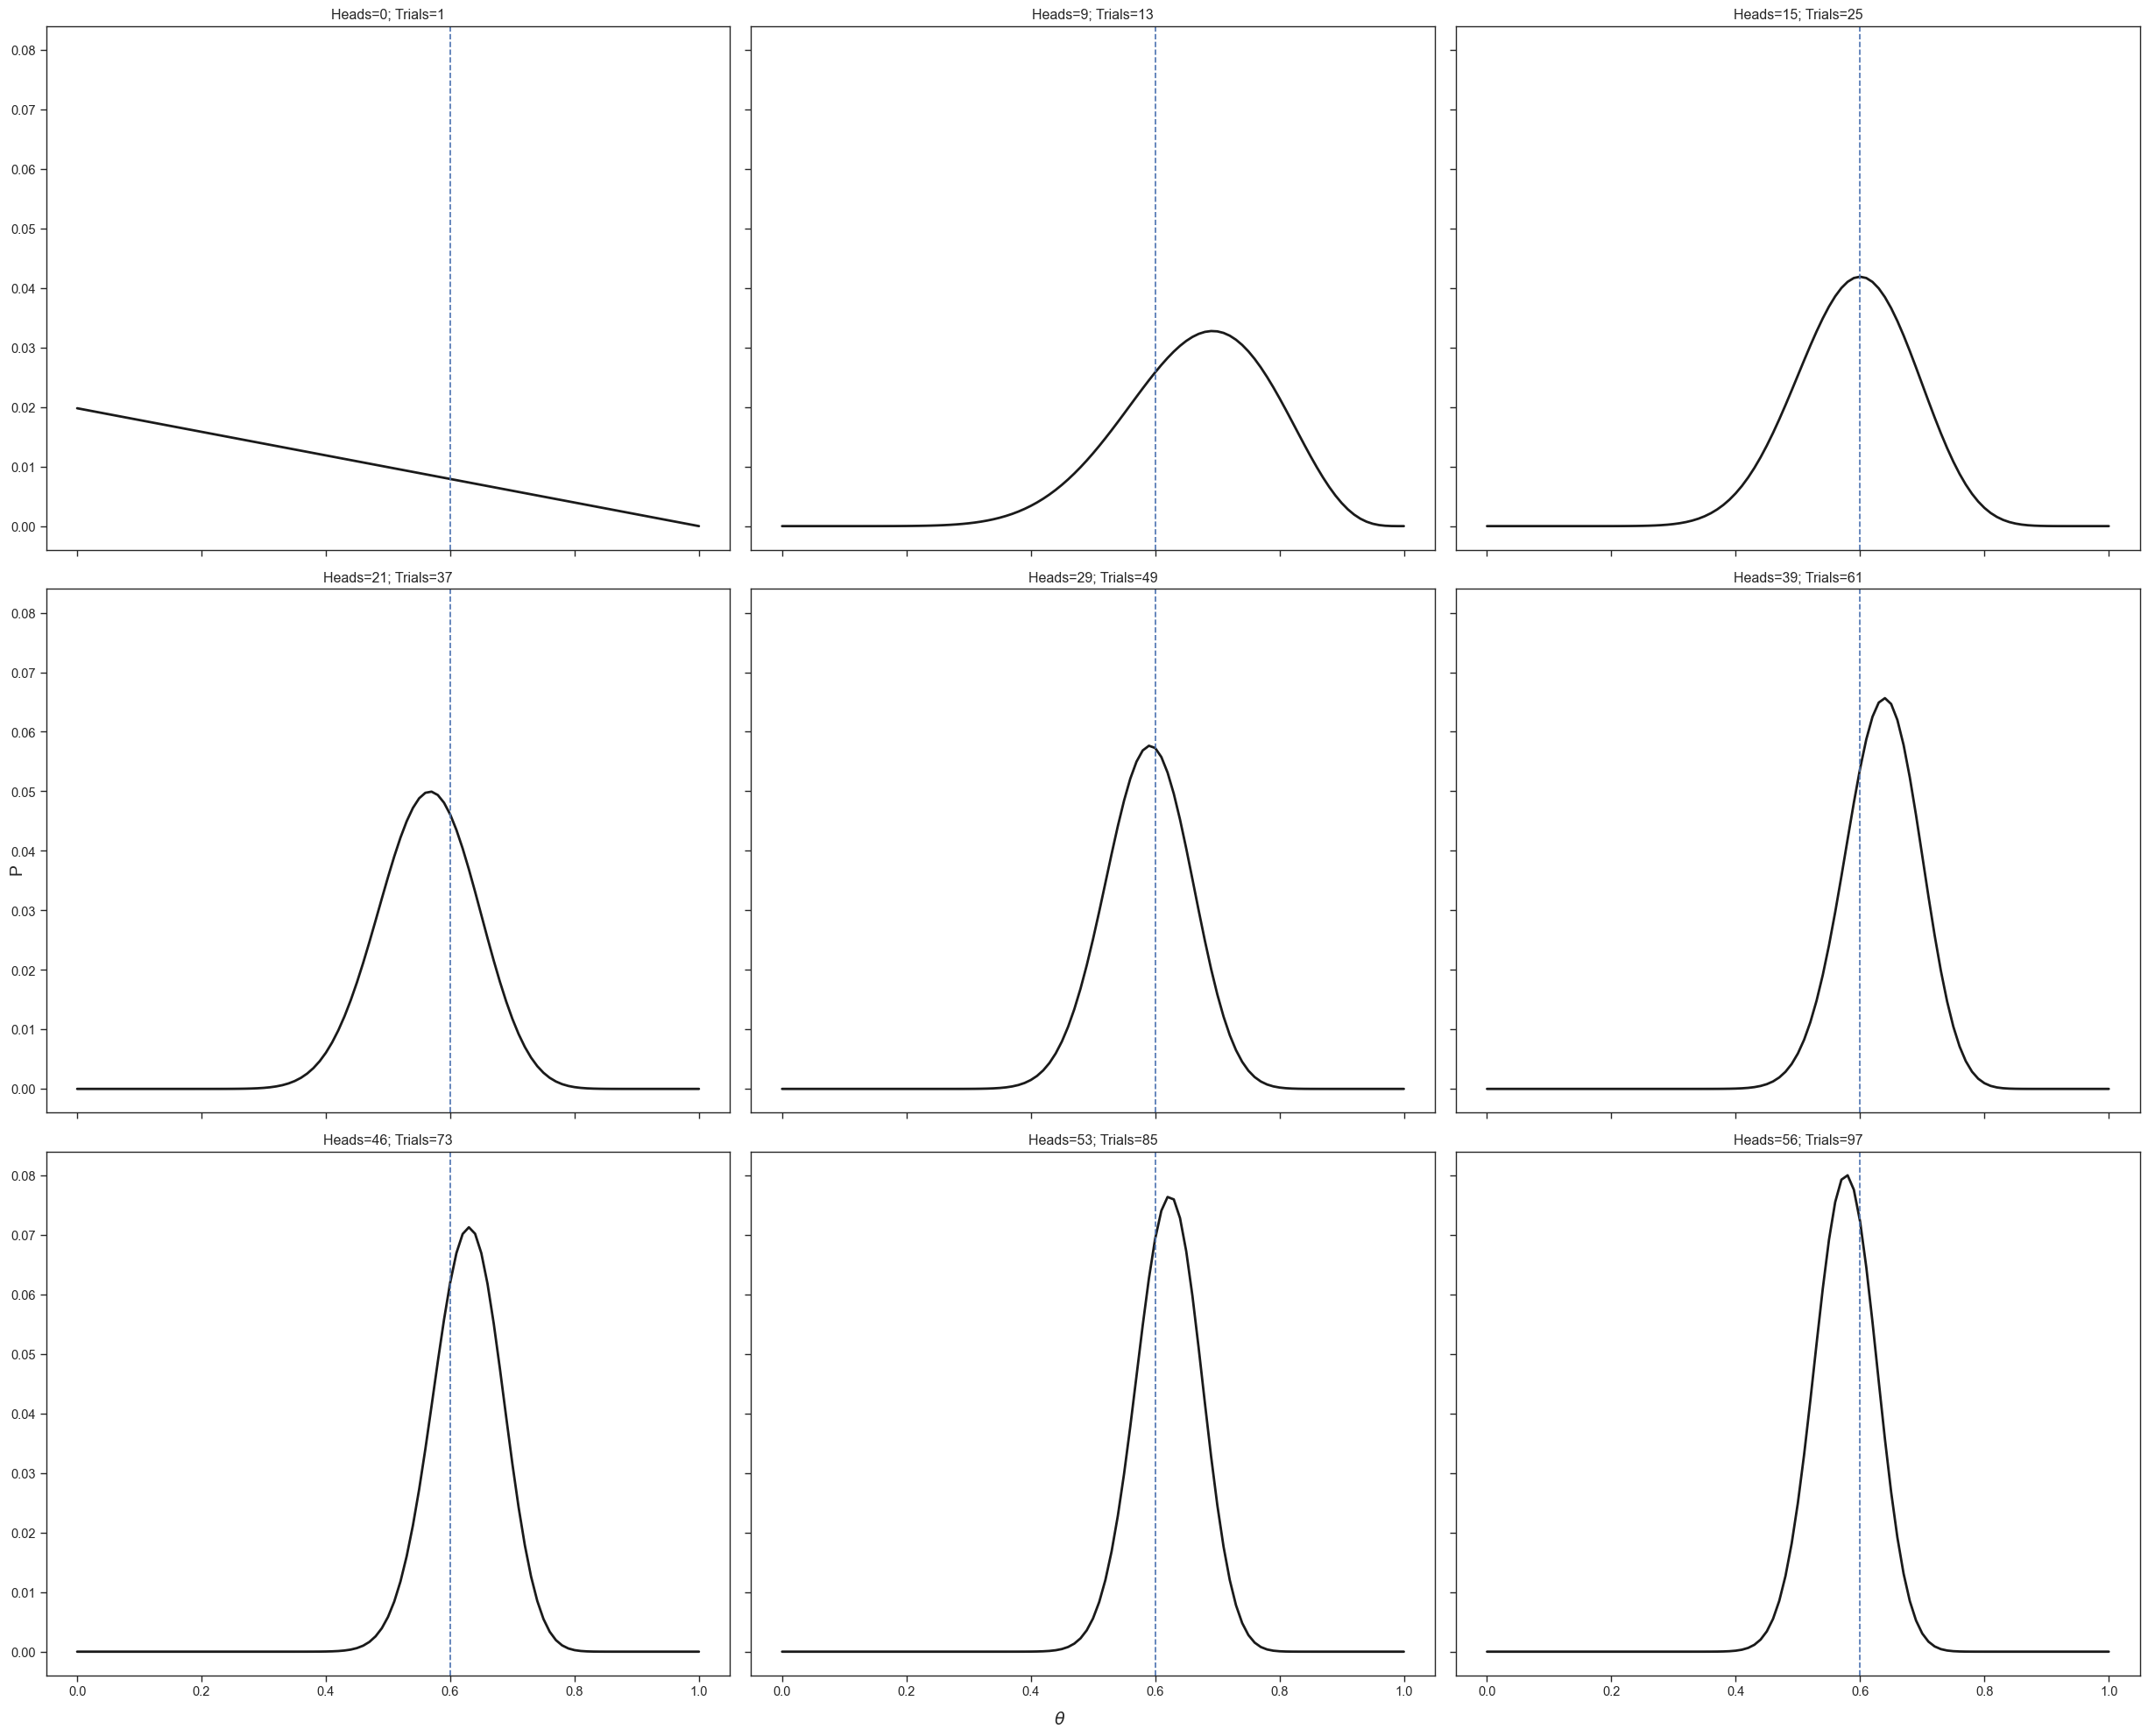

In [2]:
# Simulating a biased coin

# True underlying probability of heads
theta = 0.60
# Bunch of coin flips
data = np.array([np.random.binomial(n=1, p=theta) for x in range(100)])

# Hypothesized theta values
thetavec = np.arange(0.0, 1.001, 0.01)

# Plot the results
fig, axs = plt.subplots(3, 3, figsize=(25, 20), sharex=True, sharey=True)
n_trials = 1
for i in range(3):
    for j in range(3):
        n_heads = data[:n_trials].sum()
        n_tails = n_trials - n_heads
        post = thetavec**(n_heads) * (1 - thetavec)**(n_tails)
        post /= np.sum(post)
        axs[i, j].plot(thetavec, post, c="k", linewidth=2)
        axs[i, j].axvline(theta, linestyle="--")
        axs[i, j].set_title(f"Heads={n_heads}; Trials={n_trials}")
        n_trials = n_trials + 12
fig.supxlabel(r"$\theta$") 
fig.supylabel("P")
fig.tight_layout()
plt.show()

In [14]:
# Sanity checking - simulate 1000 experiments involving 100 coin flips
est = np.zeros(1000)
for i in range(1000):
    data = np.array([np.random.binomial(n=1, p=theta) for x in range(100)])
    n_heads = data.sum()
    n_tails = 100 - n_heads
    post = thetavec**(n_heads) * (1 - thetavec)**(n_tails)
    post /= np.sum(post)
    #est[i] = thetavec[np.argmax(post)]
    est[i] = np.sum(thetavec * post)

print(f"The PME and standard error across 1000 experiments are: {est.mean()}, {est.std()}")

The PME and standard error across 1000 experiments is: 0.5972254901960782, 0.047449472306289445


## "Recreating" Fig 6.7

- One of the keys is to correctly define the likelihood function

In [4]:
def calc_like(obs, k_hyp, s, sigma):
    # This is key part of this example: the mean of the gaussian is
    # the product of the signal strength, s, and the slope, k
    return (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(
        -((obs - (k_hyp * s)) ** 2) / (2 * sigma**2)
    )

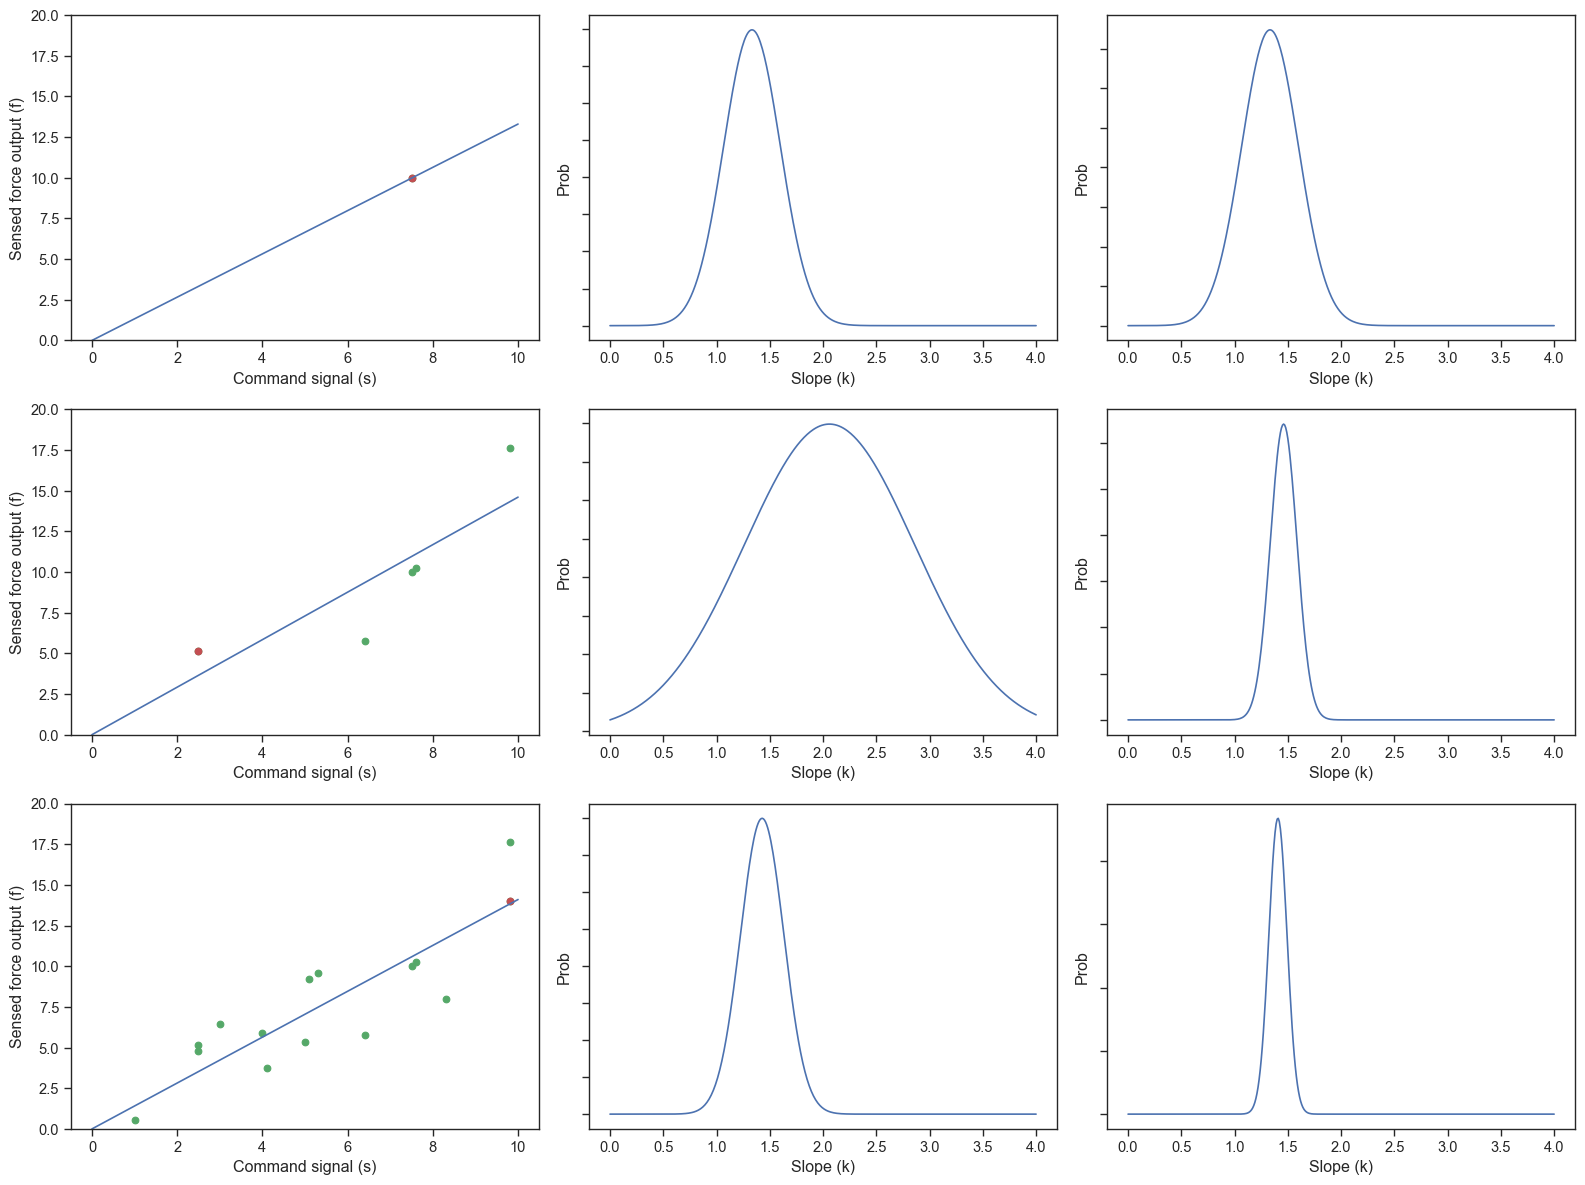

In [5]:
# These are the true parameters used to generate the data
k_true = 1.5
sigma = 2

# Make up some motor command signals
s = np.array([7.5, 7.6, 9.8, 6.4, 2.5, 4, 4.1, 5, 5.1, 5.3, 8.3, 1, 3, 2.5, 9.8])
F = k_true * s  # Force that is generated
f = np.random.normal(loc=F, scale=sigma, size=len(s))  # Force that is sensed

# Next lines are to generate straight line in figures
x = np.arange(0, 10.1)
y = k_true * x

# Create vector of hypothesized slopes
k_hyp = np.linspace(0, 4, 401)

# Compute the posterior iteratively
likelihood = np.zeros((len(s), len(k_hyp)))
post = np.zeros((len(s), len(k_hyp)))
for t in range(len(s)):
    # Compute single trial likelihood
    likelihood[t, :] = calc_like(f[t], k_hyp, s[t], sigma)
    if t == 0:
        post[t, :] = 1 * likelihood[t, :]  # Prior before first trial is uniform
    else:
        post[t, :] = post[t - 1] * likelihood[t, :]
    post[t, :] /= post[t, :].sum()

test_trial = [0, 4, 14]
fig, ax = plt.subplots(3, 3, figsize=(16, 12))
for n in range(len(test_trial)):
    ax[n, 0].plot(x, k_hyp[np.argmax(post[test_trial[n]])] * x)  # Plot PME line
    ax[n, 0].scatter(s[0 : test_trial[n] + 1], f[0 : test_trial[n] + 1], c="g")
    ax[n, 0].scatter(s[test_trial[n]], f[test_trial[n]], c="r")
    ax[n, 0].set(
        xlabel="Command signal (s)", ylim=(0, 20), ylabel="Sensed force output (f)"
    )
    ax[n, 1].plot(k_hyp, likelihood[test_trial[n], :])
    ax[n, 1].set(xlabel="Slope (k)", ylabel="Prob", yticklabels=[])
    ax[n, 2].plot(k_hyp, post[test_trial[n], :])
    ax[n, 2].set(xlabel="Slope (k)", ylabel="Prob", yticklabels=[])
fig.tight_layout()
plt.show()

![](images/fig6-8.png)

## Summary

- Learning parameters of distribution can be treated as a Bayesian inference problem, where parameters are treated as "world state"
- Formulated a posterior distribution over the rate parameter of a Bernoulli (or a binomial) distribution
- This computation involves multiplication of likelihood functions, similar to evidence accumulation and cue combination
    - Conjugate priors can facilitate easier combination of priors with new data
- Posterior predictive distribution incorporates the learning of parameters into subsequent prediction or inference (i.e., you're using the posterior to predict data/observations)
- Bayesian learning and reinforcement learning overlap in some respect
- We can use Bayesian computation to learn about the causal structure of the world from observations

## For this week and next

- Will go over more data fitting (problem 4.17) on Wednesday
- For next week
    - Read textbook: only Ch. 12.1
    - Read Jacobs tutorial on [Sensory Integration and Kalman Filtering](https://canvas.ubc.ca/courses/177413/files/folder/articles?preview=43535733) for Monday&mdash;it is excellent!
